In [1]:
import numpy as np

In [2]:
%load_ext autoreload
%autoreload 2
# Recarga automáticamente todos los módulos importados.

In [3]:
import numpy as np
import mne
from typing import List, Tuple, Union

# 1) Montaje reducido para test
montage_list_1 = ["A", "B"]
montage_list_2 = ["C", "D"]

# 2) Creamos datos sintéticos
n_samp = 5
data = np.vstack([
    np.sin(np.linspace(0,10,n_samp)),  # canal "A"
    np.cos(np.linspace(0,10,n_samp)),  # canal "B"
    np.ones(n_samp)*2,                 # canal "C"
    np.zeros(n_samp)                   # canal "D"
])
print("Data shape:", data.shape)  # (4, 10)
print("Data: ", data)

ch_names = ["A","B","C","D"]
info = mne.create_info(ch_names, sfreq=256.0)
#print info
# print("Info:", info)  # Info object with channel names and sampling frequency

# 3) Generamos un RawArray
raw_test = mne.io.RawArray(data, info)
print("Raw data: ", raw_test.get_data())  # Datos del RawArray
print("Raw ch_names:", raw_test.ch_names)  # Nombres de los canales
print("Raw times:", raw_test.times)  # Tiempos de los datos
print("Raw info:", raw_test.info)  # Información del RawArray
print("Raw info ch_names:", raw_test.info['ch_names'])  # Nombres de los canales
print("Raw info sfreq:", raw_test.info['sfreq'])  # Frecuencia de muestreo
print("Raw info nchan:", raw_test.info['nchan'])  # Número de canales
print("Raw info meas_date:", raw_test.info['meas_date'])  # Fecha de medición
print("Raw info highpass:", raw_test.info['highpass'])  # Frecuencia de corte alta
print("Raw info lowpass:", raw_test.info['lowpass'])  # Frecuencia de corte baja
print("Raw info ch_names:", raw_test.info['ch_names'])  # Nombres de los canales
print("Raw info nchan:", raw_test.info['nchan'])  # Número de canales
print("Raw info highpass:", raw_test.info['highpass'])  # Frecuencia de corte alta

# 4) Función adaptada para el test:
def get_channels_from_raw_test(
    raw: mne.io.BaseRaw
) -> Tuple[bool, Union[int, np.ndarray]]:
    # Intentamos extraer montajes reducidos
    try:
        sig1 = raw.get_data(picks=montage_list_1)
        sig2 = raw.get_data(picks=montage_list_2)
    except Exception as e:
        print("Error:", e)
        return True, 0
    return False, sig1 - sig2

# 5) Ejecutamos el test
flag, diff = get_channels_from_raw_test(raw_test)
print("Flag:", flag)            # debe ser False
print("Shape diff:", diff.shape)  # (2, 1000)
print("First 5 samples diff A-C:", diff[0, :5])  


Data shape: (4, 5)
Data:  [[ 0.          0.59847214 -0.95892427  0.93799998 -0.54402111]
 [ 1.         -0.80114362  0.28366219  0.34663532 -0.83907153]
 [ 2.          2.          2.          2.          2.        ]
 [ 0.          0.          0.          0.          0.        ]]
Creating RawArray with float64 data, n_channels=4, n_times=5
    Range : 0 ... 4 =      0.000 ...     0.016 secs
Ready.
Raw data:  [[ 0.          0.59847214 -0.95892427  0.93799998 -0.54402111]
 [ 1.         -0.80114362  0.28366219  0.34663532 -0.83907153]
 [ 2.          2.          2.          2.          2.        ]
 [ 0.          0.          0.          0.          0.        ]]
Raw ch_names: ['A', 'B', 'C', 'D']
Raw times: [0.         0.00390625 0.0078125  0.01171875 0.015625  ]
Raw info: <Info | 7 non-empty values
 bads: []
 ch_names: A, B, C, D
 chs: 4 misc
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 128.0 Hz
 meas_date: unspecified
 nchan: 4
 projs: []
 sfreq: 256.0 Hz
>
Raw info ch_names: ['A',

In [4]:
# dataset/tuh_eeg_seizure/v2.0.3/edf/train/aaaaaauj/s004_2012/01_tcp_ar/aaaaaauj_s004_t000.edf
# dataset/tuh_eeg_seizure/v2.0.3/edf/train/aaaaaedy/s002_2004/02_tcp_le/aaaaaedy_s002_t001.edf
# dataset/tuh_eeg_seizure/v2.0.3/edf/train/aaaaaedy/s003_2004/02_tcp_le/aaaaaedy_s003_t000.edf
from data_reader_2023 import *
import mne


# data_path = 'dataset/tuh_eeg_seizure/v2.0.3/edf/train/aaaaamtj/s002_2012/01_tcp_ar/aaaaamtj_s002_t000.edf'
data_path = 'dataset/tuh_eeg_seizure/v2.0.3/edf/train/aaaaaedy/s001_2004/01_tcp_ar/aaaaaedy_s001_t002.edf'
# 1. Cargo el raw (sin precargar datos en RAM)
raw = mne.io.read_raw_edf(data_path,preload=True, verbose='warning')

flag_wrong: bool
signals: np.ndarray
flag_wrong, signals = get_channels_from_raw(raw)


# # 2. Veo resumen de canales y sampling rate
# print(raw.info['ch_names'])   # ej. ['EEG FP1-REF', 'EEG F7-REF', …]
# print(raw.info['sfreq'])      # ej. 256.0 Hz

# # 3. Cargo datos en memoria
# raw.load_data()

# # 4. Miro el array numpy
# data = raw.get_data()         # shape (n_chanels, n_times)
# print(data.shape) 


# # 5. Inspecciono un fragmento y sus unidades
# print(data[0, :5])            # primeras 5 muestras del canal 0
# # (ya están en V, p. ej. [ 0.00000123, 0.00000127, … ])




montage_list_1: List[str] = ["EEG FP1-REF", "EEG F7-REF", "EEG T3-REF", "EEG T5-REF","EEG FP2-REF",
    "EEG F8-REF", "EEG T4-REF", "EEG T6-REF", "EEG T3-REF", "EEG C3-REF", "EEG CZ-REF", "EEG C4-REF",
    "EEG FP1-REF", "EEG F3-REF", "EEG C3-REF", "EEG P3-REF", "EEG FP2-REF","EEG F4-REF",
    "EEG C4-REF", "EEG P4-REF"
]
montage_list_2: List[str] = [
    "EEG F7-REF", "EEG T3-REF", "EEG T5-REF", "EEG O1-REF","EEG F8-REF", "EEG T4-REF", "EEG T6-REF",
    "EEG O2-REF", "EEG C3-REF", "EEG CZ-REF", "EEG C4-REF", "EEG T4-REF", "EEG F3-REF", "EEG C3-REF",
    "EEG P3-REF", "EEG O1-REF", "EEG F4-REF", "EEG C4-REF", "EEG P4-REF", "EEG O2-REF"
]

Número de canales : 32
Frecuencia muestreo: 400.0 Hz
Duración          : 245.0 s
Tipos de canal    : ['eeg']
Nombres de canal  : 32 canales
    1: EEG FP1-REF
    2: EEG FP2-REF
    3: EEG F3-REF
    4: EEG F4-REF
    5: EEG C3-REF
    6: EEG C4-REF
    7: EEG P3-REF
    8: EEG P4-REF
    9: EEG O1-REF
   10: EEG O2-REF
   11: EEG F7-REF
   12: EEG F8-REF
   13: EEG T3-REF
   14: EEG T4-REF
   15: EEG T5-REF
   16: EEG T6-REF
   17: EEG FZ-REF
   18: EEG CZ-REF
   19: EEG PZ-REF
   20: EEG EKG-REF
   21: EEG A1-REF
   22: EEG A2-REF
   23: EEG T1-REF
   24: EEG T2-REF
   25: EEG SP1-REF
   26: EEG SP2-REF
   27: EEG LUC-REF
   28: EEG RLC-REF
   29: EEG RESP1-REF
   30: EEG RESP2-REF
   31: EEG 31-REF
   32: EEG 32-REF
Frecuencia de cada canal:
idx:   1, nombre: EEG FP1-REF
idx:   2, nombre: EEG FP2-REF
idx:   3, nombre: EEG F3-REF
idx:   4, nombre: EEG F4-REF
idx:   5, nombre: EEG C3-REF
idx:   6, nombre: EEG C4-REF
idx:   7, nombre: EEG P3-REF
idx:   8, nombre: EEG P4-REF
idx:   9, n

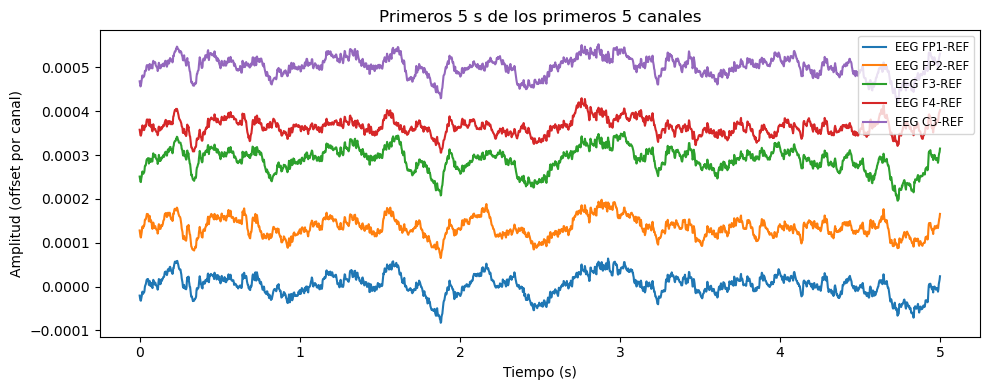

NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 5.120 (s)
Plotting power spectral density (dB=True).


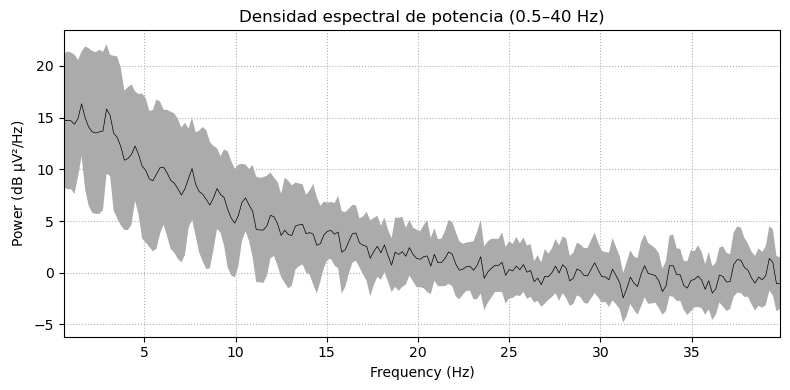

Sampling rate: 400.0


In [9]:
# 2. Llamada a la nueva función
info = summarize_raw(raw)
# 3. Accede al diccionario si lo necesitas
print("Sampling rate:", info["sfreq"])

In [6]:
a: int = sumaAlCuadrado(2,3)
print("Suma al cuadrado:", a)  # 25

Suma al cuadrado: 5


In [7]:
test_numpy: np.ndarray = np.array([1, 2, 3, 4, 5])
print("Test numpy array:", test_numpy)
print(test_numpy.shape)
print(test_numpy.dtype)
# ver que tipo es test_numpy
print("Test numpy array type:", type(test_numpy))

# test shape
# crear un array numpy de 3 x 6
print("test shape 3x6")
test_shape: np.ndarray = np.array([[1, 2, 3, 4, 5, 6],
                                   [7, 8, 9, 10, 11, 12],
                                   [13, 14, 15, 16, 17, 18]])
print("\tTest shape array:", test_shape)
print("\tTest shape array shape:", test_shape.shape)  # (3, 6)
print("\tTest shape array dtype:", test_shape.dtype)  # int64 por defecto

val: int = 5
print(f"Valor: {val}")  # Valor: 5

Test numpy array: [1 2 3 4 5]
(5,)
int64
Test numpy array type: <class 'numpy.ndarray'>
test shape 3x6
	Test shape array: [[ 1  2  3  4  5  6]
 [ 7  8  9 10 11 12]
 [13 14 15 16 17 18]]
	Test shape array shape: (3, 6)
	Test shape array dtype: int64
Valor: 5
